In [6]:
import pandas as pd
# None for sheet_names returns a dict containing data frames for each sheet
all_sheets = pd.read_excel("GreenWave_anon_kcf_export_20260416.xlsx", sheet_name=None) 
print(all_sheets.keys())

dict_keys(['User', 'Logs', 'Totals'])


In [11]:
num_nan_farms = all_sheets['Logs']['Anon Farm'].isna().sum()
num_uniq_farms = all_sheets['Logs']['Anon Farm'].nunique()
print(f"Number of unique farms: {num_uniq_farms}")
if num_nan_farms:
    print(f"Number of nan farm names: {num_nan_farms}")

Number of unique farms: 80


In [12]:
all_sheets['Logs']['Anon Farm'].value_counts()

Anon Farm
Farm_2     340
Farm_25    230
Farm_4     221
Farm_7     159
Farm_3     138
          ... 
Farm_23      4
Farm_80      3
Farm_8       1
Farm_71      1
Farm_74      1
Name: count, Length: 80, dtype: int64

In [13]:
all_sheets['Logs']['Species'].value_counts(dropna=False)

Species
sugar_kelp        1734
NaN               1620
skinny_kelp        330
alaria             264
bull_kelp          199
other_species       50
giant_kelp          36
dragon_kelp         14
split_kelp           4
three_rib_kelp       2
Name: count, dtype: int64

In [14]:
all_sheets['Logs']['Season'].value_counts(dropna=False)

Season
Season 24/25    1614
Season 23/24    1454
Season 22/23     626
Season 25/26     559
Name: count, dtype: int64

In [15]:
all_sheets['Logs']['Log Type'].value_counts(dropna=False)

Log Type
temperature         1533
sample              1441
outplanting          524
harvest              454
biofouling           133
line_loss             81
harvest_complete      77
note                  10
Name: count, dtype: int64

In [16]:
all_sheets['Logs'][all_sheets['Logs']['Log Type'] == 'harvest_complete'].head()

,Created Date,Updated Date,Anon Farm,City,State,Country,Season,Log Date,Log Type,Species,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
559,2025-08-11 17:05:17,2025-08-11 17:05:17,Farm_72,North Haven,ME,US,Season 24/25,2025-08-10,harvest_complete,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
560,2025-08-11 17:05:50,2025-08-11 17:05:50,Farm_41,Lummi Island,WA,US,Season 24/25,2025-08-10,harvest_complete,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
561,2025-08-10 23:15:41,2025-08-10 23:15:41,Farm_44,Madeira Park,BC,CA,Season 24/25,2025-08-10,harvest_complete,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
562,2025-08-06 17:41:30,2025-08-06 17:41:30,Farm_27,,NL,CA,Season 24/25,2025-08-06,harvest_complete,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,2025-07-24 19:56:09,2025-07-24 19:56:09,Farm_52,Bristol,ME,US,Season 24/25,2025-07-24,harvest_complete,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Harvest Complete rows
No weight, line length, or notes accompanying these rows. May be an timestamp for when the harvest is complete for that season. Only *77* entries for Seasons *23/24* and *24/25*

In [17]:
print(f"Total Log Entries: {len(all_sheets['Logs'])}")
print(f"\t Total Sample Logs {(all_sheets['Logs']['Log Type'] == 'sample').sum()}")
print(f"\t Total Harvest Logs {(all_sheets['Logs']['Log Type'] == 'harvest').sum()}")

Total Log Entries: 4253
	 Total Sample Logs 1441
	 Total Harvest Logs 454


In [18]:
all_sheets["Logs"].columns

Index(['Created Date', 'Updated Date', 'Anon Farm', 'City', 'State', 'Country',
       'Season', 'Log Date', 'Log Type', 'Species', 'Line Length', 'Weight',
       'Temperature', 'Notes', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20',
       'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23'],
      dtype='object')

In [19]:
# how does this look across seasons ? how many samples and harvest logs per season and per farm 
sample_harvest_logs = all_sheets["Logs"][all_sheets["Logs"]["Log Type"].isin(['sample', 'harvest'])]
counts = sample_harvest_logs.groupby(['Anon Farm', 'Season', 'Log Type']).size().unstack('Log Type', fill_value=0).reset_index()
counts

Log Type,Anon Farm,Season,harvest,sample
0,Farm_1,Season 22/23,0,20
1,Farm_1,Season 23/24,7,5
2,Farm_1,Season 24/25,2,6
3,Farm_10,Season 24/25,1,8
4,Farm_11,Season 24/25,9,11
...,...,...,...,...
151,Farm_79,Season 23/24,1,1
152,Farm_79,Season 24/25,3,4
153,Farm_79,Season 25/26,0,3
154,Farm_9,Season 23/24,2,3


In [20]:
print(f"Number of farm-seasons with >=2 samples and a harvest: {((counts['sample'] >= 2) & (counts['harvest'] > 0)).sum()}")
print(f"Number of farm-seasons with >=5 samples and a harvest: {((counts['sample'] >= 5) & (counts['harvest'] > 0)).sum()}")
print(f"Number of farm-seasons with >1 samples and > 1 harvest: {((counts['sample'] > 1) & (counts['harvest'] > 1)).sum()}")

Number of farm-seasons with >=2 samples and a harvest: 92
Number of farm-seasons with >=5 samples and a harvest: 66
Number of farm-seasons with >1 samples and > 1 harvest: 62


In [21]:
counts.to_csv('samples_harvests_per_season_per_farm.csv', index=True)

In [22]:
# how many farm seasons have both samples and harvest 
n_farm_seasons = all_sheets["Logs"].groupby(['Anon Farm', 'Season']).ngroups
print(f"Unique farm-seasons (all log types): {n_farm_seasons}")
counts.columns.name = None
counts = counts.rename(columns={"sample" : "n_samples", "harvest" : "n_harvests"})
print(f"Farm-seasons with sample or harvest logs : {len(counts)}")
print(f"    Both samples and harvests: {((counts['n_samples'] > 0) & (counts['n_harvests'] >0)).sum()}")
# what is the length of a season?
all_sheets['Logs']['Log Date'] = pd.to_datetime(all_sheets['Logs']['Log Date'])
season_spans = all_sheets["Logs"].groupby(["Anon Farm", "Season"]).agg(first_log=('Log Date', 'min'), last_log=('Log Date', 'max')).reset_index()
season_spans['n_days'] = (season_spans['last_log'] - season_spans['first_log']).dt.days
season_spans.to_csv('season_spans_per_farm.csv', index=True)
# different kelp species per farm per season?
species_per_fs = all_sheets['Logs'].dropna(subset=['Species']).groupby(["Anon Farm", "Season"]).agg(n_species=('Species', 'nunique'), species_list=('Species', lambda s: ", ".join(sorted(s.unique())))).reset_index()
print(f"Farm-seasons growing >1 species: {(species_per_fs['n_species'] > 1).sum()}")

Unique farm-seasons (all log types): 181
Farm-seasons with sample or harvest logs : 156
    Both samples and harvests: 102
Farm-seasons growing >1 species: 66


### Create analysis table of farm-season per species per line with sample and harvest data

In [25]:
logs = all_sheets['Logs']
logs = logs.loc[:, ~logs.columns.str.startswith('Unnamed')]
logs['Log Date'] = pd.to_datetime(logs['Log Date'])

/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_79155/3792141069.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logs['Log Date'] = pd.to_datetime(logs['Log Date'])


In [26]:
import re
def extract_line_numbers(note) -> list:
    found = []
    if isinstance(note, str):
        # \b creates a boundary around the word -- must be standalone
        # ? makes the char in front optional
        # \s = space []* match zero or more separator characters
        # capture each number along with any separators between each
        # optionally capture any numbers followed by and
        for match in re.finditer(r'\blines?\b[\s:=>/]*([\d,\s&]+(?:and[\s\d,&]+)*)', note.lower()):
            for c in re.findall(r'\d+', match.group(1)):
                num = int(c)
                if num not in found:
                    found.append(num)
        found.sort()
    return found

logs['line_numbers'] = logs['Notes'].apply(extract_line_numbers)
logs['n_lines'] = logs['line_numbers'].apply(len)
logs[logs['n_lines'] >1].head()

/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_79155/1674364272.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logs['line_numbers'] = logs['Notes'].apply(extract_line_numbers)
/var/folders/8p/z1k7jgpx2dj57tsnh25vy08c0000gn/T/ipykernel_79155/1674364272.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  logs['n_lines'] = logs['line_numbers'].apply(len)


,Created Date,Updated Date,Anon Farm,City,State,Country,Season,Log Date,Log Type,Species,Line Length,Weight,Temperature,Notes,line_numbers,n_lines
208,2026-02-22 22:54:54,2026-02-22 22:54:54,Farm_12,Casco Bay,ME,US,Season 25/26,2026-02-22,sample,alaria,NaN,1.03,NaN,Line 2 sample. Length 48-60”. Good density. Li...,"[1, 2]",2
499,2025-11-11 00:02:36,2025-11-11 00:02:36,Farm_12,Casco Bay,ME,US,Season 25/26,2025-11-08,outplanting,skinny_kelp,3750.0,NaN,NaN,"Lines 5, 6, and 7. Line 6 double seeded with t...","[5, 6, 7]",3
517,2025-11-05 00:17:35,2025-11-05 00:17:35,Farm_12,Casco Bay,ME,US,Season 25/26,2025-11-02,outplanting,alaria,2000.0,NaN,NaN,Line 1 and 2 (closest to shore/NW side). 30ft ...,"[1, 2]",2
518,2025-11-05 00:17:36,2025-11-10 23:59:35,Farm_12,Casco Bay,ME,US,Season 25/26,2025-11-02,outplanting,sugar_kelp,3000.0,NaN,NaN,Lines 3 and 4. 17.5ft separation. Line 4 doubl...,"[3, 4]",2
634,2025-06-19 18:58:33,2025-06-19 18:58:33,Farm_25,Branford,CT,US,Season 24/25,2025-06-03,harvest,sugar_kelp,780.0,622.00,NaN,"Lines 4,5 [Recreated by GF]","[4, 5]",2


In [27]:
# explore logs that have more than 1 line mentioned
multi_lines_logs = logs[(logs['n_lines'] >1) & logs['Log Type'].isin(['sample', 'harvest'])]
print(f"Number of sample/harvest logs with more than 1 line recorded: {len(multi_lines_logs)}")
print(f"Number of multi line logs with a sample and harvest match: 0 (can see below)")
pd.set_option('display.max_colwidth', 500)
multi_lines_logs[['Anon Farm', 'Season', 'Log Type', 'Notes', 'line_numbers']].sort_values(by=['Anon Farm', 'Season', 'Log Type'], ascending=[True, True, False])

Number of sample/harvest logs with more than 1 line recorded: 11
Number of multi line logs with a sample and harvest match: 0 (can see below)


,Anon Farm,Season,Log Type,Notes,line_numbers
1105,Farm_12,Season 24/25,harvest,Lines 3 & 4. Line 3 had sparse growth in sections\n[Recreated],"[3, 4]"
1106,Farm_12,Season 24/25,harvest,Lines 3 and 4. Line 3 had several areas where kelp was sparse. Some snails with early signs of predation.\n[Recreated],"[3, 4]"
1107,Farm_12,Season 24/25,harvest,Lines 3 & 4. Continued light weight and length with some sparse sections. Line 3 - 2 full bags. Line 4 - 3 full bags. Some snails with early signs of predation [Recreated],"[3, 4]"
1126,Farm_12,Season 24/25,harvest,Lines 1 & 2. Some snails with isolated areas of predation.,"[1, 2]"
1305,Farm_12,Season 24/25,harvest,First harvest day. Lines 7 & 8. Much lighter weight than usual. Minimal signs of bio fouling. Temperature probe retrieved.,"[7, 8]"
208,Farm_12,Season 25/26,sample,Line 2 sample. Length 48-60”. Good density. Line 1 Alaria is sparse,"[1, 2]"
2093,Farm_25,Season 24/25,sample,First observed kelp growth on lines 1 and 7 outplanted on October 17 at 63°F,"[1, 7]"
634,Farm_25,Season 24/25,harvest,"Lines 4,5 [Recreated by GF]","[4, 5]"
640,Farm_25,Season 24/25,harvest,"Lines => 12,11,10,6 [Recreated by GF]","[6, 10, 11, 12]"
2532,Farm_26,Season 23/24,harvest,"Lines 6,7,8,9,10","[6, 7, 8, 9, 10]"


In [28]:
# build a line and species key 
def line_key(row):
    if row['n_lines'] == 0:
        return 'unspecified'
    if row['n_lines'] == 1:
        return str(row['line_numbers'][0])
    return 'multi: ' + ','.join(map(str, row['line_numbers']))

sh = logs[logs['Log Type'].isin(['sample', 'harvest'])].copy()
sh['line_key'] = sh.apply(line_key, axis=1)
sh['species_key'] = sh['Species'].fillna('unspecified')
sh.head()

,Created Date,Updated Date,Anon Farm,City,State,Country,Season,Log Date,Log Type,Species,Line Length,Weight,Temperature,Notes,line_numbers,n_lines,line_key,species_key
1,2026-04-16 15:26:31,2026-04-16 15:26:31,Farm_25,Branford,CT,US,Season 25/26,2026-04-16,harvest,sugar_kelp,80.0,66.00,NaN,Line 6 harvest,[6],1,6,sugar_kelp
8,2026-04-15 17:43:28,2026-04-15 17:43:28,Farm_55,Craig,AK,US,Season 25/26,2026-04-13,sample,sugar_kelp,NaN,0.10,NaN,"Cell 6, line 3\nNo growth",[3],1,3,sugar_kelp
9,2026-04-15 17:43:28,2026-04-15 17:43:28,Farm_55,Craig,AK,US,Season 25/26,2026-04-13,sample,sugar_kelp,NaN,0.70,NaN,"Cell 4, line 6",[6],1,6,sugar_kelp
10,2026-04-15 17:43:28,2026-04-15 17:43:28,Farm_55,Craig,AK,US,Season 25/26,2026-04-13,sample,sugar_kelp,NaN,0.13,NaN,"Cell 8, line 9\n",[9],1,9,sugar_kelp
11,2026-04-15 17:43:28,2026-04-15 17:43:28,Farm_55,Craig,AK,US,Season 25/26,2026-04-13,sample,sugar_kelp,NaN,1.60,NaN,"Cell 2, line 8",[8],1,8,sugar_kelp


In [29]:
print(f"Number of sample/harvest logs that specify a species + line: {((sh['line_key'] != 'unspecified') & (sh['species_key'] !='unspecified')).sum()}")
print(f"Number of sample/harvest logs that specify a species + no line: {((sh['line_key'] == 'unspecified') & (sh['species_key'] !='unspecified')).sum()}")

Number of sample/harvest logs that specify a species + line: 229
Number of sample/harvest logs that specify a species + no line: 1666


In [30]:
# create the summary table 
def summarize(group):
    # per a farm, season, species, and line collect the samples and harvests = 1 row 
    # sort samples and harvests by date 
    samples = group[group['Log Type'] == 'sample'].sort_values('Log Date')
    harvests = group[group['Log Type'] == 'harvest'].sort_values('Log Date')
    return pd.Series({
        'n_samples': len(samples),
        'n_samples_before_1st_harvest': (samples['Log Date'] < harvests['Log Date'].min()).sum(),
        'sample_dates': samples['Log Date'].dt.strftime('%Y-%m-%d').tolist(),
        'sample_weights': samples['Weight'].tolist(),
        'first_sample_date': samples['Log Date'].dt.strftime('%Y-%m-%d').min() if len(samples) else pd.NaT,
        'last_sample_date': samples['Log Date'].dt.strftime('%Y-%m-%d').max() if len(samples) else pd.NaT,
        'n_harvests': len(harvests),
        'harvest_dates': harvests['Log Date'].dt.strftime('%Y-%m-%d').tolist(),
        'harvest_weights': harvests['Weight'].tolist(),
        'harvest_lengths': harvests['Line Length'].tolist(),
        'harvest_yields': [round(weight / line_length, 2) for weight, line_length in zip(harvests['Weight'].tolist(), harvests['Line Length'].tolist()) if line_length >0],
        'first_harvest_date': harvests['Log Date'].dt.strftime('%Y-%m-%d').min() if len(harvests) else pd.NaT,
        'last_harvest_date': harvests['Log Date'].dt.strftime('%Y-%m-%d').max() if len(harvests) else pd.NaT,
        'days_last_sample_to_first_harvest': ((harvests['Log Date'].min() - samples['Log Date'].max()).days if len(samples) and len(harvests) else None),
        'is_sample_harvest_overlap': (True if (harvests['Log Date'].min() < samples['Log Date'].max()) else False),
    })

detail_table = sh.groupby(['Anon Farm', 'Season', 'species_key', 'line_key']).apply(summarize, include_groups=False).reset_index().rename(columns={'species_key' : 'Species', 'line_key' : 'Line'})

detail_table.head()

,Anon Farm,Season,Species,Line,n_samples,n_samples_before_1st_harvest,sample_dates,sample_weights,first_sample_date,last_sample_date,n_harvests,harvest_dates,harvest_weights,harvest_lengths,harvest_yields,first_harvest_date,last_harvest_date,days_last_sample_to_first_harvest,is_sample_harvest_overlap
0,Farm_1,Season 22/23,alaria,unspecified,8,0,"[2023-03-25, 2023-03-25, 2023-04-29, 2023-04-29, 2023-04-29, 2023-06-09, 2023-06-09, 2023-06-09]","[0.32, 0.48, 1.2, 0.9, 1.3, 3.9, 3.7, 5.6]",2023-03-25,2023-06-09,0,[],[],[],[],NaT,NaT,NaN,False
1,Farm_1,Season 22/23,sugar_kelp,unspecified,12,0,"[2023-03-05, 2023-03-05, 2023-03-05, 2023-03-25, 2023-03-25, 2023-03-25, 2023-04-29, 2023-04-29, 2023-04-29, 2023-06-09, 2023-06-09, 2023-06-09]","[0.13, 0.05, 0.21, 1.7, 1.9, 1.8, 3.0, 2.9, 3.2, 10.2, 9.7, 10.5]",2023-03-05,2023-06-09,0,[],[],[],[],NaT,NaT,NaN,False
2,Farm_1,Season 23/24,bull_kelp,unspecified,1,1,[2024-05-11],[0.0],2024-05-11,2024-05-11,1,[2024-06-23],[2745.0],[6000.0],[0.46],2024-06-23,2024-06-23,43.0,False
3,Farm_1,Season 23/24,sugar_kelp,unspecified,4,1,"[2024-05-11, 2024-06-07, 2024-06-17, 2024-06-27]","[0.25, 1.2, 3.0, 3.65]",2024-05-11,2024-06-27,6,"[2024-05-13, 2024-05-19, 2024-07-08, 2024-07-09, 2024-07-10, 2024-07-11]","[200.0, 823.0, 3650.0, 3000.0, 4800.0, 4100.0]","[400.0, 1600.0, 1200.0, 1400.0, 1600.0, 2000.0]","[0.5, 0.51, 3.04, 2.14, 3.0, 2.05]",2024-05-13,2024-07-11,-45.0,True
4,Farm_1,Season 24/25,bull_kelp,unspecified,0,0,[],[],NaT,NaT,1,[2025-06-23],[0.21],[8000.0],[0.0],2025-06-23,2025-06-23,NaN,False


### Farm-season-species-line data table
How much valid data do we have?

In [31]:
# drop rows that do not have a sample and harvest
print(f"Length of farm-season-species-line table: {len(detail_table)}")
sh_detail_table = detail_table[(detail_table['n_samples']>0)&(detail_table['n_harvests']>0)].copy()
print(f"    Number of rows with at least 1 sample and harvest: {len(sh_detail_table)} ")
print(f"    Number of rows with >= 2 samples and harvest: {(sh_detail_table['n_samples']>1).sum()} ")
print(f"    Number of rows with >= 5 samples and harvest: {(sh_detail_table['n_samples']>4).sum()} ")
print(f"        Number of rows with at least 1 sample before a harvest: {(sh_detail_table['n_samples_before_1st_harvest']>0).sum()} ")
print(f"        Number of rows with multiple harvests (with at least 1 sample): {((sh_detail_table['n_harvests']>1)).sum()} ")
print(f"            Number of rows with multiple harvests and overlap with samples: {((sh_detail_table['n_harvests']>1)&(sh_detail_table['is_sample_harvest_overlap'])).sum()}")
print(f"    Number of rows with line + species: {((sh_detail_table['Species'] != 'unspecified') & (sh_detail_table['Line'] != 'unspecified')).sum()}")
print(f"    Number of rows with no line + species: {((sh_detail_table['Species'] != 'unspecified') & (sh_detail_table['Line'] == 'unspecified')).sum()}")
print(f"    Number of rows with multi line: {(sh_detail_table['Line'].str.count('multi')).sum()}")
print(f"    Number of rows with line + no species: {((sh_detail_table['Species'] == 'unspecified') & (sh_detail_table['Line'] != 'unspecified')).sum()}")
print(f"    Number of rows with no line + no species: {((sh_detail_table['Species'] == 'unspecified') & (sh_detail_table['Line'] == 'unspecified')).sum()}")

Length of farm-season-species-line table: 313
    Number of rows with at least 1 sample and harvest: 138 
    Number of rows with >= 2 samples and harvest: 113 
    Number of rows with >= 5 samples and harvest: 67 
        Number of rows with at least 1 sample before a harvest: 132 
        Number of rows with multiple harvests (with at least 1 sample): 63 
            Number of rows with multiple harvests and overlap with samples: 18
    Number of rows with line + species: 10
    Number of rows with no line + species: 128
    Number of rows with multi line: 0
    Number of rows with line + no species: 0
    Number of rows with no line + no species: 0


In [32]:
# add data quality tier flag... easy to read classification of what the row entails
def add_tag(row):
    has_species = row['Species'] != 'unspecified'
    is_multi_lines = row['Line'].startswith('multi')
    single_line = row['Line'] != 'unspecified' and not is_multi_lines
    if has_species and single_line: return '1_species_and_single_line'
    if has_species and is_multi_lines: return '2_species_and_multi_line' # none in this dataset
    if has_species: return '3_species_only'
    if single_line: return '4_line_only' # none in this dataset
    if is_multi_lines: return '5_multi_line_only' # none in this dataset
    return '6_no_species_no_line' # none in this dataset

sh_detail_table['data_quality'] = sh_detail_table.apply(add_tag, axis=1)
sh_detail_table['data_quality'].value_counts().sort_index()

data_quality
1_species_and_single_line     10
3_species_only               128
Name: count, dtype: int64

In [33]:
# save to csv 
# need to convert lists to strings for csv output
for col in ['sample_dates', 'sample_weights', 'harvest_dates', 'harvest_weights', 'harvest_lengths', 'harvest_yields']:
    sh_detail_table[col] = sh_detail_table[col].apply(lambda x: ", ".join(map(str, x)) if isinstance(x, list) else x)

sh_detail_table.sort_values(['data_quality', 'Anon Farm', 'Season', 'Species', 'Line'], ascending=[True, True, True, True, True]).to_csv('sample_harvest_detail_table.csv', index=False)

### Plot Growth across a Season 
For a farm-season-species-line, plot the samples and harvests yield (lb/ft) by date 

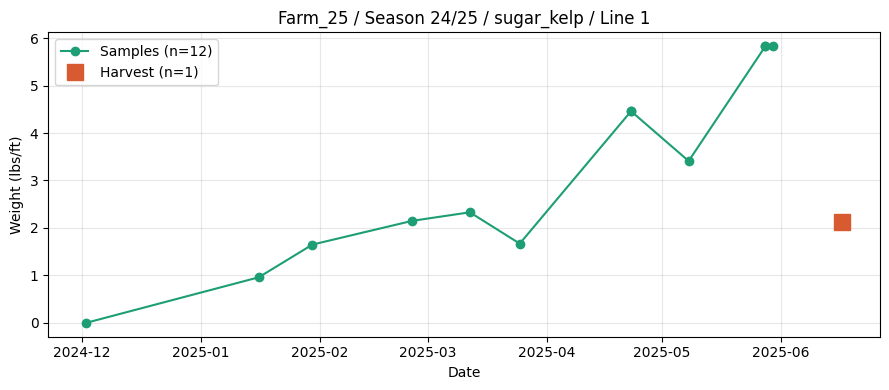

In [35]:
import matplotlib.pyplot as plt

def plot_group(farm, season, species, line):
    """Show samples-over-time + harvest event for one (farm,season,species,line) group."""
    mask = ((sh['Anon Farm']==farm) & (sh['Season']==season)
            & (sh['species_key']==species) & (sh['line_key']==str(line)))
    g = sh[mask]
    samples  = g[g['Log Type']=='sample'].sort_values('Log Date')
    harvests = g[g['Log Type']=='harvest'].sort_values('Log Date')

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(samples['Log Date'], samples['Weight'], 'o-', color='#1D9E75',
            label=f'Samples (n={len(samples)})')
    for _, h in harvests.iterrows():
        if not h['Line Length']:
            raise ValueError("Line length is 0")
        yld = h['Weight'] / h['Line Length']
        ax.plot(h['Log Date'], yld, 's', color='#D85A30', markersize=11,
                label=f'Harvest (n={len(harvests)})')
    ax.set_xlabel('Date'); ax.set_ylabel('Weight (lbs/ft)')
    ax.set_title(f'{farm} / {season} / {species} / Line {line}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

# Example:
plot_group('Farm_25', 'Season 24/25', 'sugar_kelp', 1)

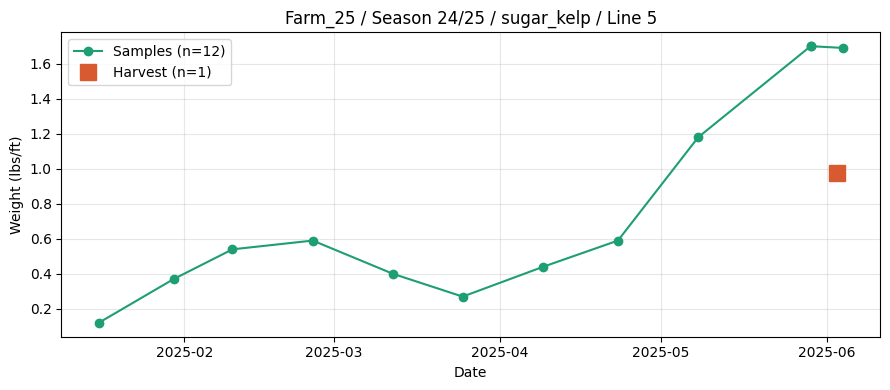

In [36]:
plot_group('Farm_25', 'Season 24/25', 'sugar_kelp', 5)

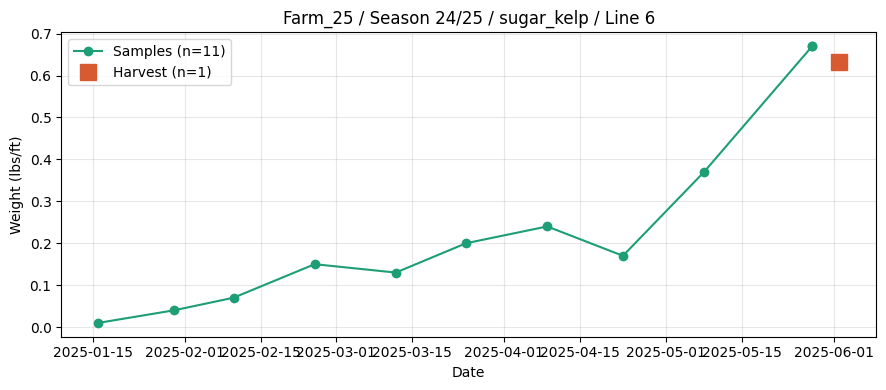

In [37]:
plot_group('Farm_25', 'Season 24/25', 'sugar_kelp', 6)

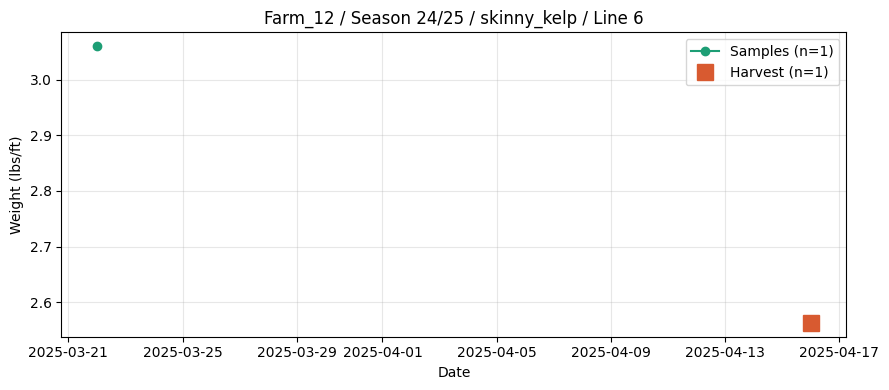

In [38]:
plot_group('Farm_12', 'Season 24/25', 'skinny_kelp', 6)

### Sample weight distribution vs harvest yield

For each farm-season-species-line group that has both samples and a harvest, compute:
- **mean sample weight** — average of all individual sample weights (lbs)
- **std sample weight** — standard deviation; how variable growth was across sampling dates
- **mean harvest yield** — average lbs/ft across all harvest events

Then check whether either statistic correlates with final harvest yield.

In [39]:
import numpy as np

# detail_table still has list-typed columns (string conversion only modified sh_detail_table)
analytic = detail_table[(detail_table['n_samples'] > 0) & (detail_table['n_harvests'] > 0)].copy()

def _clean(lst):
    return [w for w in lst if w is not None and not (isinstance(w, float) and np.isnan(w))]

analytic['mean_sample_weight'] = analytic['sample_weights'].apply(
    lambda ws: np.nanmean(_clean(ws)) if _clean(ws) else np.nan
)
analytic['std_sample_weight'] = analytic['sample_weights'].apply(
    lambda ws: np.std(_clean(ws), ddof=1) if len(_clean(ws)) >= 2 else np.nan
)
analytic['mean_harvest_yield'] = analytic['harvest_yields'].apply(
    lambda ys: np.nanmean(ys) if ys else np.nan
)

valid = analytic.dropna(subset=['mean_sample_weight', 'mean_harvest_yield'])
print(f"Groups with valid mean sample weight + harvest yield: {len(valid)}")
print(f"  Of those, with std (>=2 samples): {valid['std_sample_weight'].notna().sum()}")
print()
print(valid[['Anon Farm', 'Season', 'Species', 'n_samples',
             'mean_sample_weight', 'std_sample_weight', 'mean_harvest_yield']].round(3).to_string(index=False))

Groups with valid mean sample weight + harvest yield: 138
  Of those, with std (>=2 samples): 113

Anon Farm       Season       Species  n_samples  mean_sample_weight  std_sample_weight  mean_harvest_yield
   Farm_1 Season 23/24     bull_kelp          1               0.000                NaN               0.460
   Farm_1 Season 23/24    sugar_kelp          4               2.025              1.573               1.873
   Farm_1 Season 24/25    sugar_kelp          6               2.027              3.088               1.830
  Farm_10 Season 24/25    sugar_kelp          8               2.870              1.879               6.500
  Farm_11 Season 24/25   skinny_kelp          5               2.402              2.151               6.526
  Farm_11 Season 24/25    sugar_kelp          6               2.500              1.934               5.880
  Farm_12 Season 24/25   skinny_kelp          1               2.430                NaN               2.940
  Farm_12 Season 24/25   skinny_kelp         

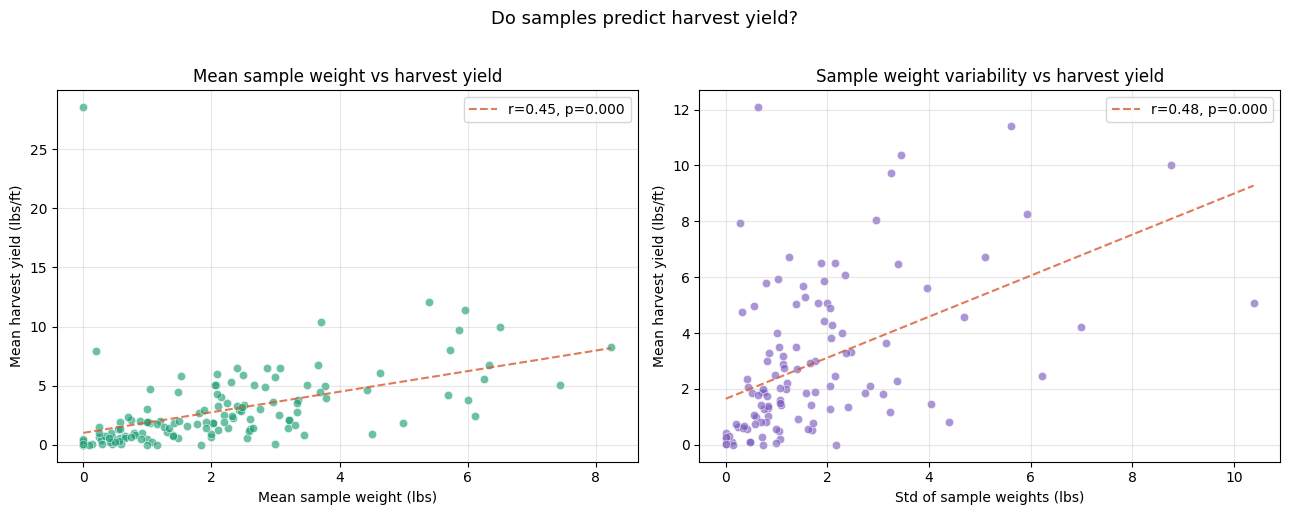

In [41]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- left: mean sample weight vs mean harvest yield ---
ax = axes[0]
ax.scatter(valid['mean_sample_weight'], valid['mean_harvest_yield'],
           alpha=0.65, color='#1D9E75', edgecolors='white', linewidths=0.5)
r, p = stats.pearsonr(valid['mean_sample_weight'], valid['mean_harvest_yield'])
m, b = np.polyfit(valid['mean_sample_weight'], valid['mean_harvest_yield'], 1)
xs = np.linspace(valid['mean_sample_weight'].min(), valid['mean_sample_weight'].max(), 100)
ax.plot(xs, m * xs + b, '--', color='#D85A30', alpha=0.8, label=f'r={r:.2f}, p={p:.3f}')
ax.set_xlabel('Mean sample weight (lbs)')
ax.set_ylabel('Mean harvest yield (lbs/ft)')
ax.set_title('Mean sample weight vs harvest yield')
ax.legend(); ax.grid(alpha=0.3)

# --- right: std sample weight vs mean harvest yield ---
std_valid = valid.dropna(subset=['std_sample_weight'])
ax = axes[1]
ax.scatter(std_valid['std_sample_weight'], std_valid['mean_harvest_yield'],
           alpha=0.65, color='#7C5CBF', edgecolors='white', linewidths=0.5)
if len(std_valid) >= 3:
    r2, p2 = stats.pearsonr(std_valid['std_sample_weight'], std_valid['mean_harvest_yield'])
    m2, b2 = np.polyfit(std_valid['std_sample_weight'], std_valid['mean_harvest_yield'], 1)
    xs2 = np.linspace(std_valid['std_sample_weight'].min(), std_valid['std_sample_weight'].max(), 100)
    ax.plot(xs2, m2 * xs2 + b2, '--', color='#D85A30', alpha=0.8, label=f'r={r2:.2f}, p={p2:.3f}')
    ax.legend()
ax.set_xlabel('Std of sample weights (lbs)')
ax.set_ylabel('Mean harvest yield (lbs/ft)')
ax.set_title('Sample weight variability vs harvest yield')
ax.grid(alpha=0.3)

plt.suptitle('Do samples predict harvest yield?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Add residual and z_score columns
### How far off are the sample from harvest yields (mean)? Prediction error 
*Residual* = mean_harvest_yield - mean_sample_weight

*z-score* = residual /std_sample_weight (scale residual by how noisy sampling was)



In [63]:
z_valid = valid.copy()
z_valid['residual'] = z_valid['mean_harvest_yield'] - z_valid['mean_sample_weight']
z_valid['z_score'] = np.where(valid['std_sample_weight'].fillna(0) > 0,
                              z_valid['residual'] / valid['std_sample_weight'], 
                              np.nan)
n_groups = len(z_valid)
n_with_z = z_valid['z_score'].notna().sum()
print(f"Total groups with samples+harvest: {n_groups}")
print(f"  Of those with z-score defined (std > 0): {n_with_z}")
print()
print("Residual (lbs):")
print(f"  Mean:   {z_valid['residual'].mean():+.2f}")
print(f"  Median: {z_valid['residual'].median():+.2f}")
print(f"  Std:    {z_valid['residual'].std():.2f}")
print()
z = z_valid['z_score'].dropna()
print("Z-score:")
print(f"  Mean:   {z.mean():+.2f}")
print(f"  Median: {z.median():+.2f}")
within_2 = ((z >= -2) & (z <= 2)).mean()
print(f"  Within +/-2: {within_2*100:.0f}%")

Total groups with samples+harvest: 138
  Of those with z-score defined (std > 0): 108

Residual (lbs):
  Mean:   +0.74
  Median: +0.16
  Std:    3.02

Z-score:
  Mean:   +0.89
  Median: +0.19
  Within +/-2: 89%


Harvest was ~0.7 lbs/ft than the sample mean predicted. ~90% of the time the harvest was within 2 standard deviations of the sample mean. 

Positive bias could be due to sampling happening mid growth, difference in choosing sample versus harvest? (do farmers harvest everything or only the densest parts)?

## Sample Distribution versus Harvest 
Does the harvest land inside the distribution/cloud of sample measurements?
- each sample yield is represented as a dot
- horizontal lean showing the sample mean
- harvest yield is an orange square 

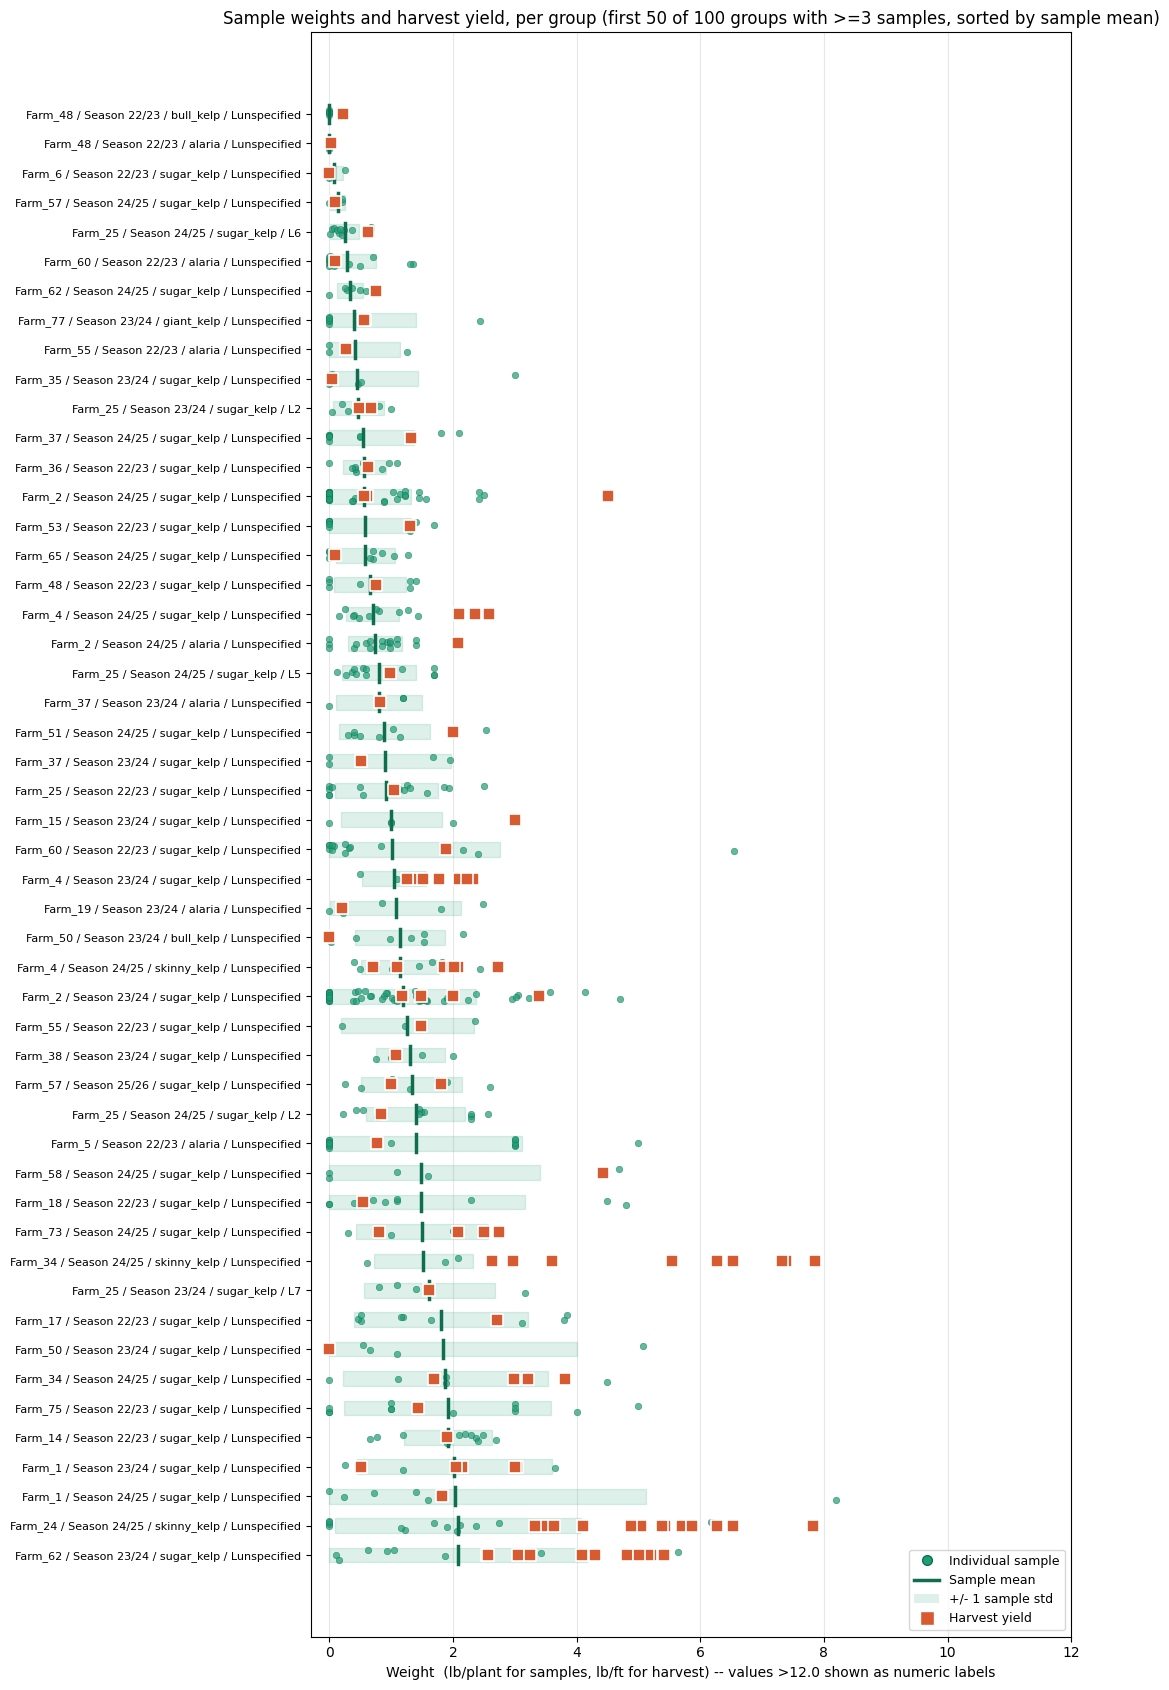

In [67]:
# Filter to groups with >=3 samples first -- the chart needs enough points
# per row to actually visualize a distribution. Then sort by mean sample weight.
df_sorted = (z_valid[z_valid['n_samples'] >= 3]
             .sort_values('mean_sample_weight')
             .reset_index(drop=True))

SHOW_N = 50
top = df_sorted.head(SHOW_N)

# Cap the x-axis so a few extreme harvest yields (one outlier hits ~80 lb/ft)
# don't squash everything else. Anything past the cap gets drawn as an arrow
# at the cap with the actual value annotated.
X_CAP = 12.0

fig, ax = plt.subplots(figsize=(11, max(6, 0.34 * SHOW_N)))

for i, row in top.iterrows():
    weights = [w for w in row['sample_weights']
               if w is not None and not (isinstance(w, float) and np.isnan(w))]
    if not weights:
        continue

    # vertical band of jitter so overlapping samples are visible
    jitter = np.random.uniform(-0.18, 0.18, size=len(weights))
    # Clamp x values to the cap; mark clamped ones with a different edge
    in_range_x = [w for k, w in enumerate(weights) if w <= X_CAP]
    in_range_y = [i + jitter[k] for k, w in enumerate(weights) if w <= X_CAP]
    out_range = [w for w in weights if w > X_CAP]
    if in_range_x:
        ax.scatter(in_range_x, in_range_y,
                   color='#1D9E75', s=22, alpha=0.7,
                   edgecolors='#0F6E50', linewidths=0.4, zorder=3)
    for w in out_range:
        ax.annotate(f'{w:.1f}>', xy=(X_CAP - 0.05, i), xytext=(X_CAP - 0.05, i),
                    color='#0F6E50', fontsize=7, ha='right', va='center')

    # sample mean as a short vertical line (visual anchor)
    mean_w = min(np.mean(weights), X_CAP)
    ax.plot([mean_w, mean_w], [i - 0.3, i + 0.3],
            color='#0F6E50', linewidth=2.5, zorder=4)

    # +/- 1 std as a thin shaded band, only if we have >=2 samples
    if len(weights) >= 2:
        std_w = np.std(weights, ddof=1)
        band_lo = max(np.mean(weights) - std_w, 0)
        band_hi = min(np.mean(weights) + std_w, X_CAP)
        if band_hi > band_lo:
            ax.fill_betweenx([i - 0.25, i + 0.25], band_lo, band_hi,
                             color='#1D9E75', alpha=0.15, zorder=2)

    # harvest yields as orange squares, with off-scale annotation
    for y in row['harvest_yields']:
        if y <= X_CAP:
            ax.scatter([y], [i], color='#D85A30', marker='s', s=85,
                       edgecolors='white', linewidths=1.2, zorder=5)
        else:
            ax.annotate(f'  {y:.1f}>', xy=(X_CAP - 0.1, i),
                        xytext=(X_CAP - 0.1, i),
                        color='#D85A30', fontsize=8, fontweight='bold',
                        ha='right', va='center', zorder=5)

labels = [f"{r['Anon Farm']} / {r['Season']} / {r['Species']} / L{r['Line']}"
          for _, r in top.iterrows()]
ax.set_yticks(range(SHOW_N))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlim(-0.3, X_CAP)
ax.set_xlabel(f'Weight  (lb/plant for samples, lb/ft for harvest) -- values >{X_CAP} shown as numeric labels')
ax.set_title(f'Sample weights and harvest yield, per group (first {SHOW_N} of {len(df_sorted)} groups with >=3 samples, sorted by sample mean)')
ax.grid(alpha=0.3, axis='x')
ax.invert_yaxis()  # smallest at top reads more naturally

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1D9E75',
           markeredgecolor='#0F6E50', markersize=7, label='Individual sample'),
    Line2D([0], [0], color='#0F6E50', linewidth=2.5, label='Sample mean'),
    Patch(facecolor='#1D9E75', alpha=0.15, label='+/- 1 sample std'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#D85A30',
           markeredgecolor='white', markersize=10, label='Harvest yield'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

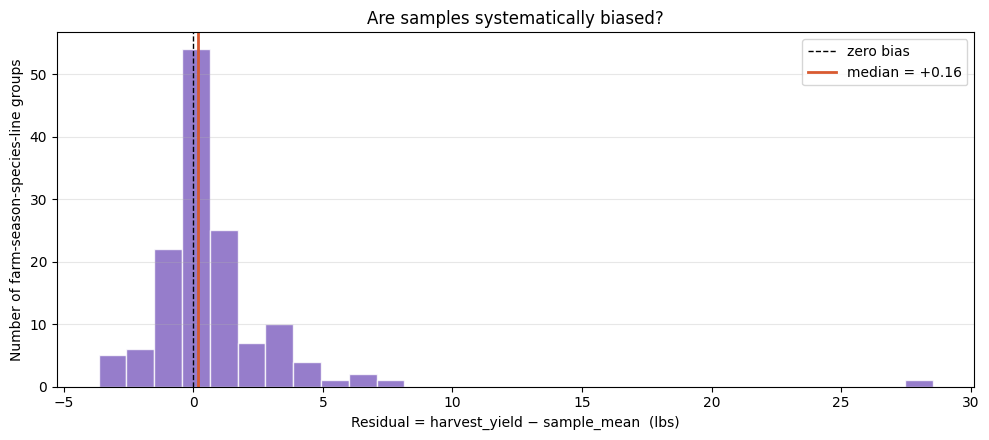

In [65]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(z_valid['residual'], bins=30, color='#7C5CBF', alpha=0.8, edgecolor='white')

# reference lines: zero bias and the actual median
ax.axvline(0, color='black', linewidth=1, linestyle='--', label='zero bias')
median_resid = z_valid['residual'].median()
ax.axvline(median_resid, color='#D85A30', linewidth=2,
           label=f'median = {median_resid:+.2f}')

ax.set_xlabel('Residual = harvest_yield − sample_mean  (lbs)')
ax.set_ylabel('Number of farm-season-species-line groups')
ax.set_title('Are samples systematically biased?')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

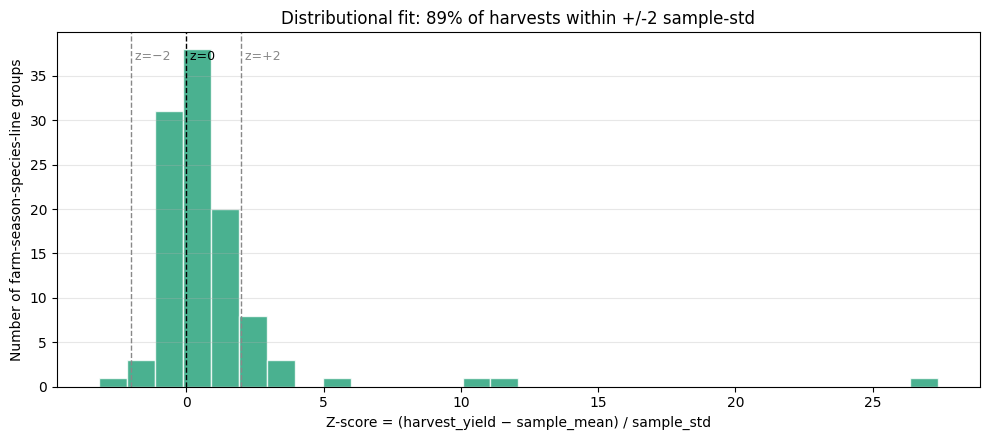

In [66]:
z = z_valid['z_score'].dropna()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(z, bins=30, color='#1D9E75', alpha=0.8, edgecolor='white')

# reference lines at z = -2, 0, +2
for zval, color in [(-2, '#888'), (0, 'black'), (2, '#888')]:
    ax.axvline(zval, color=color, linewidth=1, linestyle='--')
ax.text(-2, ax.get_ylim()[1] * 0.95, ' z=−2', color='#888', va='top', fontsize=9)
ax.text(0, ax.get_ylim()[1] * 0.95, ' z=0', color='black', va='top', fontsize=9)
ax.text(2, ax.get_ylim()[1] * 0.95, ' z=+2', color='#888', va='top', fontsize=9)

within_2 = ((z >= -2) & (z <= 2)).mean()
ax.set_xlabel('Z-score = (harvest_yield − sample_mean) / sample_std')
ax.set_ylabel('Number of farm-season-species-line groups')
ax.set_title(f'Distributional fit: {within_2*100:.0f}% of harvests within +/-2 sample-std')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()